In [1]:
import os
import csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pdal
import geopandas as gpd
import laspy
from laspy import CopcReader
import shapely
from shapely.geometry import box
from scipy.spatial import cKDTree
from concurrent.futures import ThreadPoolExecutor, as_completed

In [2]:
df = gpd.read_file("merged_results.gpkg")

In [6]:
df

,IDU,row_spacing,plant_spacing,rmse,points_expected,points_found,area_missing_pct,index,AREA,SUP,...,Designation_Level,min_row_spacing,max_row_spacing,min_plant_spacing,max_plant_spacing,max_area,source,notes,tier,geometry
0,070090000A0635,2.5,0.5,0.870,187.0,158.0,15.51,827,305.0,305.0,...,Sub-regional,NaN,2.5,NaN,NaN,2.3,https://eur-lex.europa.eu/eli/C/2024/5920/oj,None,2,"POLYGON ((840379.17 6462204.45, 840359.34 6462..."
1,070090000A0805,2.2,0.6,0.934,546.0,469.0,14.10,866,790.0,790.0,...,Sub-regional,NaN,2.5,NaN,NaN,2.3,https://eur-lex.europa.eu/eli/C/2024/5920/oj,None,2,"POLYGON ((840171.13 6462152.59, 840172.36 6462..."
2,070090000A0837,2.0,1.6,1.034,329.0,265.0,19.45,879,1125.0,1125.0,...,Sub-regional,NaN,2.5,NaN,NaN,2.3,https://eur-lex.europa.eu/eli/C/2024/5920/oj,None,2,"POLYGON ((840842.96 6461890.76, 840843.28 6461..."
3,070090000B0212,2.5,0.8,1.044,358.0,249.0,30.45,913,810.0,810.0,...,Sub-regional,NaN,2.5,NaN,NaN,2.3,https://eur-lex.europa.eu/eli/C/2024/5920/oj,None,2,"POLYGON ((840207.49 6461082.68, 840236.12 6461..."
4,070090000B0317,1.3,1.5,1.114,251.0,189.0,24.70,931,1320.0,1320.0,...,Sub-regional,NaN,2.5,NaN,NaN,2.3,https://eur-lex.europa.eu/eli/C/2024/5920/oj,None,2,"POLYGON ((840947.32 6460743.84, 840962.96 6460..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,841510000A0395,2.2,0.8,1.145,869.0,578.0,33.49,176245,1640.0,1640.0,...,Sub-regional,NaN,2.5,0.8,1.2,NaN,https://eur-lex.europa.eu/eli/C/2025/4405/oj,None,2,"POLYGON ((908435.4 6303226.48, 908382.1 630317..."
4996,841510000A0455,2.5,0.8,1.294,17880.0,7883.0,55.91,176252,36505.0,21476.0,...,Sub-regional,NaN,2.5,0.8,1.2,NaN,https://eur-lex.europa.eu/eli/C/2025/4405/oj,None,2,"POLYGON ((908534.89 6303471.88, 908535.17 6303..."
4997,841510000A0476,2.2,0.8,1.222,659.0,401.0,39.15,176253,1384.0,700.0,...,Sub-regional,NaN,2.5,0.8,1.2,NaN,https://eur-lex.europa.eu/eli/C/2025/4405/oj,None,2,"POLYGON ((908659.76 6303592.89, 908677.16 6303..."
4998,841510000B0349,2.4,0.8,1.292,1758.0,807.0,54.10,176275,3740.0,3740.0,...,Sub-regional,NaN,2.5,0.8,1.2,NaN,https://eur-lex.europa.eu/eli/C/2025/4405/oj,None,2,"POLYGON ((908741.38 6304974.81, 908740 6304977..."


<Axes: >

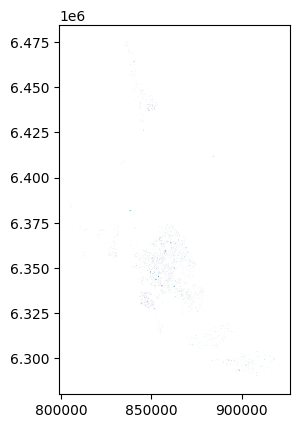

In [8]:
df.plot(column = 'area_missing_pct')